# Model training — reviewer-feedback response, part 2 ("Strongly recommended" items)

This notebook continues from `model_training_based_on_reviewer_feedback.ipynb` (which
covered the "Essential" items) and addresses the five "Strongly recommended" items from
`plan_for_addressing_some_concerns.txt`:

7. Raw vs. Gaussian-smoothed prediction performance, and confirmation of how boundary
   frames are actually handled in the reported metrics.
8. Full parameter reporting for the heading-correction procedure, a sensitivity analysis
   on the convex-optimization weight ratio, and per-stage trajectory counts.
9. Leave-one-wind-speed-out generalization, and error stratified by wind speed and by
   upwind/crosswind/downwind flight direction.
10. A complete dataset-flow table, from raw parquet files to the final training set.
11. An out-of-distribution input check and an ensemble-based per-prediction confidence
    estimate.

This notebook reuses the exact trajectory split and models produced by the first
notebook — it reloads `pipelinedata/reviewer_response/trajectory_split_ids.csv` and
`models/model_reviewer_response_full.keras` / `model_reviewer_response_thrust_ablated.keras`
rather than re-deriving them, so results here are directly comparable to Part 1. The
architecture hyperparameters selected by Part 1's grouped grid search
(full model: 2 layers x 20 neurons; thrust-ablated model: 3 layers x 15 neurons) are
reused here where a new model needs to be trained (leave-one-wind-out, extra ensemble
seeds) rather than re-running the expensive grid search — this trade-off is the same one
made for the secondary ablations in Part 1, and is noted explicitly rather than left
implicit.

## 1. Setup — reload the Part 1 split and trained models

In [1]:
import os
import sys
import random
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy

sys.path.insert(0, os.path.abspath('../utils'))

from utils import (
    pull_out_individual_trajectories,
    augment_with_time_delay_embedding,
    naive_heading_correction,
    circular_distance,
    wrapToPi,
    create_model,
)

import keras
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import GroupShuffleSplit

RESPONSE_DIR = '../pipelinedata/reviewer_response'
os.makedirs(RESPONSE_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

TIME_WINDOW = 4
input_names_full = ['groundspeed', 'groundspeed_angle',
                     'airspeed', 'airspeed_angle',
                     'thrust', 'thrust_angle']
n_input_full = len(input_names_full) * TIME_WINDOW
n_output = 2
KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']

# hyperparameters selected by Part 1's grouped grid search (Section 5 / Section 7)
BEST_PARAMS_FULL = {'layers': 2, 'neurons': 20}
BEST_PARAMS_ABLATED = {'layers': 3, 'neurons': 15}


def embed(trajectories, input_names, time_window, wind_augment=False):
    kwargs = dict(time_window=time_window, input_names=input_names,
                  output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding(
        trajectories, wind_augment=wind_augment, wrap_angles=wind_augment, **kwargs
    )


def split_X_y_groups(df, n_input):
    X = df.iloc[:, 0:n_input].reset_index(drop=True)
    y = df[['heading_angle_x', 'heading_angle_y']].reset_index(drop=True)
    groups = df['trajec_objid'].reset_index(drop=True)
    return X, y, groups


final_fly_data = pd.read_csv(
    '../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv'
)
fly_traj_list = pull_out_individual_trajectories(final_fly_data, min_traj_length=12)

split_record = pd.read_csv(f'{RESPONSE_DIR}/trajectory_split_ids.csv')
train_ids = set(split_record.loc[split_record['split'] == 'train', 'trajec_objid'])
test_ids = set(split_record.loc[split_record['split'] == 'test', 'trajec_objid'])

train_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in train_ids]
test_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in test_ids]
print(f"Reloaded split: {len(train_trajectories)} train / {len(test_trajectories)} test trajectories")

train_original_full = embed(train_trajectories, input_names_full, TIME_WINDOW, wind_augment=False)
train_wind_full = embed(train_trajectories, input_names_full, TIME_WINDOW, wind_augment=True)
train_all_full = pd.concat([train_original_full, train_wind_full], ignore_index=True)
test_embedded_full = embed(test_trajectories, input_names_full, TIME_WINDOW, wind_augment=False)

X_train_full, y_train_full, groups_train_full = split_X_y_groups(train_all_full, n_input_full)
X_test_full, y_test_full, groups_test_full = split_X_y_groups(test_embedded_full, n_input_full)

model_full = keras.models.load_model('../models/model_reviewer_response_full.keras', safe_mode=False)
model_abl = keras.models.load_model('../models/model_reviewer_response_thrust_ablated.keras', safe_mode=False)
print("Loaded Part 1 models.")

I0000 00:00:1788945187.914211 1842724 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788945187.914792 1842724 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788945187.953983 1842724 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788945189.190162 1842724 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788945189.190540 1842724 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Detected 2386 trajectories.


2340 trajectories with more than 12 timesteps.
Reloaded split: 1569 train / 771 test trajectories


Loaded Part 1 models.


E0000 00:00:1788945211.449065 1842724 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Reusable evaluation utilities (same as Part 1, redefined here for a standalone notebook)

In [2]:
def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def per_trajectory_errors(trajec_id_values, err_deg):
    return (
        pd.DataFrame({'trajec_objid': trajec_id_values, 'abs_angular_error_deg': err_deg})
        .groupby('trajec_objid')['abs_angular_error_deg']
        .median()
    )


def bootstrap_median_ci(values, n_boot=2000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boots = rng.choice(values, size=(n_boot, len(values)), replace=True)
    boot_medians = np.median(boots, axis=1)
    lo, hi = np.percentile(boot_medians, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return float(np.median(values)), float(lo), float(hi)


THRESHOLD_DEG = 15.0


def summarize_model(per_traj_series, label):
    med, lo, hi = bootstrap_median_ci(per_traj_series.values)
    return {
        'model': label,
        'n_trajectories': int(len(per_traj_series)),
        'median_per_traj_error_deg': med,
        'ci95_lo_deg': lo,
        'ci95_hi_deg': hi,
        'iqr_low_deg': float(np.percentile(per_traj_series, 25)),
        'iqr_high_deg': float(np.percentile(per_traj_series, 75)),
        f'pct_trajectories_exceeding_{THRESHOLD_DEG:g}deg': float(
            (per_traj_series > THRESHOLD_DEG).mean() * 100
        ),
    }


def grouped_inner_val_split(X, y, groups, val_fraction=0.2, seed=123):
    unique_groups = groups.unique()
    gss = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    dummy = np.zeros((len(unique_groups), 1))
    subtrain_gidx, val_gidx = next(gss.split(dummy, groups=unique_groups))
    subtrain_ids = set(unique_groups[subtrain_gidx])
    val_ids = set(unique_groups[val_gidx])
    m_sub = groups.isin(subtrain_ids)
    m_val = groups.isin(val_ids)
    return (X[m_sub].values, y[m_sub].values), (X[m_val].values, y[m_val].values)


def fit_final_model(X, y, groups, n_input, neurons, layers, seed=RANDOM_SEED,
                     epochs=150, batch_size=256):
    # clear_session() first: this notebook calls fit_final_model many times in a row
    # (leave-one-wind-out x3, ensemble seeds x3+) - without clearing the Keras/TF backend
    # between calls, graphs and thread pools accumulate across calls and can degrade into
    # a near-hang on a busy, shared machine.
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)
    (Xtr, ytr), (Xval, yval) = grouped_inner_val_split(X, y, groups)
    model = create_model(n_input=n_input, n_output=n_output, neurons=neurons, layers=layers)
    model.fit(Xtr, ytr, validation_data=(Xval, yval),
              epochs=epochs, batch_size=batch_size, verbose=0)
    return model

## 2. Raw vs. Gaussian-smoothed predictions, and boundary-frame handling (Item 7)

**What:** for every held-out test trajectory, the full-feature model's raw
(unsmoothed) predicted heading is computed by embedding the trajectory exactly as
`test_embedded_full` already is (i.e. the same `(n - 3)`-row table used for every
metric in Part 1 — no repeated boundary frames are ever added here). Gaussian
smoothing (`scipy.ndimage.gaussian_filter1d`) is then applied to the predicted
`(x, y)` components at `sigma = 1`, `sigma = 2` (the value `plot_trajectory_with_predicted_heading`
uses by default), and `sigma = 4`, before recomputing the heading via `arctan2`.

**Why:** Reviewer #1 (major comment 10) points out that `plot_trajectory_with_predicted_heading(..., smooth=True)`
applies Gaussian smoothing to predictions, and asks whether the manuscript's reported
error uses raw or smoothed output, plus whether boundary frames (padded by repeating the
first prediction) are included.

**Finding on boundary frames:** the padding-by-repetition Reviewer #1 describes exists
only inside `plot_trajectory_with_predicted_heading`'s `_predict_heading` helper, which
pads the first `W-1` positions purely so the plotted arrow sequence lines up with
`position_x`/`position_y` for visualization. `collect_offset_rows` (the function that
actually builds every embedded feature/target table used for training and evaluation,
including `test_embedded_full`) *drops* the first `W-1` frames of each trajectory
entirely rather than padding them — it returns `(n - w + 1)` rows, not `n`. Every metric
reported in Part 1 and below is computed on `test_embedded_full`, so boundary frames were
never included in any reported accuracy number; the padding only ever affected the
qualitative overlay figures. This is confirmed programmatically below.

In [3]:
# Confirm no boundary-frame padding in the metrics pipeline: each trajectory contributes
# exactly (len(trajectory) - TIME_WINDOW + 1) rows to test_embedded_full, never len(trajectory).
# Note: one trajec_objid ('20130406_172248_4749') corresponds to two temporally
# disjoint 46-row segments in the source file (pull_out_individual_trajectories splits
# on each timestamp reset to 0.00, and this id happens to appear twice). This is a
# genuine data quirk, not a bug in this notebook - the check below sums contributions
# per trajec_objid rather than assuming one physical trajectory per id, so it is robust
# to it.
check_counts = test_embedded_full.groupby('trajec_objid').size()
expected_counts = (
    pd.DataFrame({
        'trajec_objid': [t['trajec_objid'].iloc[0] for t in test_trajectories],
        'n': [len(t) - TIME_WINDOW + 1 for t in test_trajectories],
    })
    .groupby('trajec_objid')['n']
    .sum()
)
assert (check_counts.sort_index() == expected_counts.sort_index()).all(), \
    "embedded row counts should equal len(trajectory) - TIME_WINDOW + 1 with no padding"
print("Confirmed: test_embedded_full contains no boundary-frame padding "
      "(row count per trajectory == len(trajectory) - (TIME_WINDOW - 1), "
      "summed over any trajec_objid that maps to more than one physical segment).")

Confirmed: test_embedded_full contains no boundary-frame padding (row count per trajectory == len(trajectory) - (TIME_WINDOW - 1), summed over any trajec_objid that maps to more than one physical segment).


In [4]:
def predict_raw_and_smoothed(trajectory, model, sigmas):
    embedded = embed([trajectory], input_names_full, TIME_WINDOW, wind_augment=False)
    X = embedded.iloc[:, 0:n_input_full].values
    y_true = embedded[['heading_angle_x', 'heading_angle_y']].values
    raw_pred = model.predict(X, verbose=0)
    trajec_id = embedded['trajec_objid'].values
    out = {'raw': (y_true, raw_pred, trajec_id)}
    for sigma in sigmas:
        smoothed_pred = gaussian_filter1d(raw_pred, sigma=sigma, axis=0)
        out[f'sigma={sigma}'] = (y_true, smoothed_pred, trajec_id)
    return out


sigmas_to_test = [1, 2, 4]
smoothing_results = {key: {'y_true': [], 'y_pred': [], 'trajec_id': []}
                     for key in ['raw'] + [f'sigma={s}' for s in sigmas_to_test]}

for traj in test_trajectories:
    per_traj_out = predict_raw_and_smoothed(traj, model_full, sigmas_to_test)
    for key, (y_true, y_pred, trajec_id) in per_traj_out.items():
        smoothing_results[key]['y_true'].append(y_true)
        smoothing_results[key]['y_pred'].append(y_pred)
        smoothing_results[key]['trajec_id'].append(trajec_id)

smoothing_summary = []
smoothing_per_traj = {}
for key, parts in smoothing_results.items():
    y_true = np.concatenate(parts['y_true'])
    y_pred = np.concatenate(parts['y_pred'])
    trajec_id = np.concatenate(parts['trajec_id'])
    err = angular_error_deg(y_true, y_pred)
    per_traj = per_trajectory_errors(trajec_id, err)
    label = f'ANN (full features), prediction = {key}'
    summary = summarize_model(per_traj, label)
    smoothing_summary.append(summary)
    smoothing_per_traj[label] = per_traj

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(pd.DataFrame(smoothing_summary).sort_values('median_per_traj_error_deg').to_string(index=False))

                                    model  n_trajectories  median_per_traj_error_deg  ci95_lo_deg  ci95_hi_deg  iqr_low_deg  iqr_high_deg  pct_trajectories_exceeding_15deg
ANN (full features), prediction = sigma=2             771                   5.325163     4.923061     5.786849     3.157397      9.247215                         14.915694
ANN (full features), prediction = sigma=1             771                   5.361951     5.010257     5.812477     3.145101      9.119208                         14.526589
    ANN (full features), prediction = raw             771                   5.550665     5.237439     5.944871     3.358832      9.207122                         14.785992
ANN (full features), prediction = sigma=4             771                   5.744689     5.297209     6.359661     3.342453      9.593305                         15.564202


**Significance:** Production's sigma=2 default turns out to be close to optimal among the values tested: 5.55 (raw) -> 5.36 (sigma=1) -> 5.33 (sigma=2) -> 5.74 (sigma=4) deg — a real but modest ~0.2 deg improvement over raw, with over-smoothing (sigma=4) starting to hurt. This directly answers Reviewer #1 (major comment 10): the manuscript's reported error needs to state explicitly whether it used raw or sigma=2-smoothed predictions, since the two differ by a measurable amount. Combined with the boundary-frame confirmation just above, none of the ~5.3-5.7 deg numbers reported anywhere in this response include the padded/repeated first-(W-1) predictions the reviewer flagged — that padding only ever affected the qualitative overlay plots, never a reported accuracy number.

## 3. Dataset flow, from raw parquet files to the final training set (Item 10)

**What:** trajectory and frame counts are read directly from each pipeline stage's
saved file, from the raw Dryad parquet files through `pipelinedata/06_final`, plus the
duration distribution of the final retained trajectories and the exact
train/validation/test split sizes used throughout this response.

**Why:** Reviewer #1 (major comment 9) notes the abstract cites 2,340 training
trajectories while the Results section cites 64,026 total frames, and asks for a full
accounting of what was removed at each stage and whether "2,340" refers to all retained
trajectories or training-only. This table answers that question for the pipeline as it
actually runs today — the counts below do **not** match either the reviewer-quoted
manuscript numbers or the numbers in the current `paper/*.tex` draft (3,313 test
trajectories / 101,576 frames), which is consistent with the version-mismatch flagged
separately and remains an open manuscript-reconciliation item (see
`plan_for_addressing_some_concerns.txt`, item 12) — it is not resolved here.

In [5]:
raw_counts = {}
for ws in ['30cms', '40cms', '60cms']:
    trajec_df = pd.read_parquet(f'../experimentaldata/{ws}/flight_trajectories_3d_HCS_odor_horizon_matched.parquet')
    raw_counts[ws] = {'trajectories': trajec_df['objid'].nunique(), 'frames': len(trajec_df)}

stage_files = {
    '01_merged (post body-orientation join, >12 frames)':
        '../pipelinedata/01_merged/all_wind_heading_and_trajectories.csv',
    '02_augmented (kinematic features added)':
        '../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv',
    '03_corrected (naive + convex-opt heading correction)':
        '../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv',
    '04_filtered (residual pi-flip trajectories removed)':
        '../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv',
    '05_smoothed (Savitzky-Golay smoothing)':
        '../pipelinedata/05_smoothed/all_wind_heading_and_trajectories_augmented_corrected_filtered_smoothed.csv',
    '06_final (heading_angle_x/y added; training input)':
        '../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv',
}

flow_rows = []
for ws, c in raw_counts.items():
    flow_rows.append({'stage': f'raw parquet ({ws})', 'trajectories': c['trajectories'], 'frames': c['frames']})
flow_rows.append({
    'stage': 'raw parquet (all wind speeds, combined)',
    'trajectories': sum(c['trajectories'] for c in raw_counts.values()),
    'frames': sum(c['frames'] for c in raw_counts.values()),
})
for label, path in stage_files.items():
    df = pd.read_csv(path)
    flow_rows.append({'stage': label, 'trajectories': df['trajec_objid'].nunique(), 'frames': len(df)})

rejected = pd.read_csv('../pipelinedata/04_filtered/rejected_trajectories.csv')
flow_rows.append({
    'stage': '  -> removed at 04_filtered (residual circular jump >= pi/2)',
    'trajectories': rejected['trajec_objid'].nunique(),
    'frames': len(rejected),
})

flow_df = pd.DataFrame(flow_rows)
flow_df.to_csv(f'{RESPONSE_DIR}/dataset_flow_table.csv', index=False)
print(flow_df.to_string(index=False))

                                                       stage  trajectories  frames
                                         raw parquet (30cms)          1739 1646598
                                         raw parquet (40cms)          1428 1549743
                                         raw parquet (60cms)          1386 1561296
                     raw parquet (all wind speeds, combined)          4553 4757637
          01_merged (post body-orientation join, >12 frames)          3339  113886
                     02_augmented (kinematic features added)          3339  113886
        03_corrected (naive + convex-opt heading correction)          3339  113886
         04_filtered (residual pi-flip trajectories removed)          2338   71145
                      05_smoothed (Savitzky-Golay smoothing)          2338   71145
          06_final (heading_angle_x/y added; training input)          2338   71145
  -> removed at 04_filtered (residual circular jump >= pi/2)          1001   42741


In [6]:
durations = pd.Series({t['trajec_objid'].iloc[0]: t['timestamp'].max() for t in fly_traj_list})
print("Final retained trajectory duration (s), summary statistics:")
print(durations.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

n_train_traj = len(train_trajectories)
n_test_traj = len(test_trajectories)

unique_train_ids = groups_train_full.unique()
gss_check = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
dummy = np.zeros((len(unique_train_ids), 1))
subtrain_idx, val_idx = next(gss_check.split(dummy, groups=unique_train_ids))

print(f"\nTrajectory-level split used throughout this response:")
print(f"  Train trajectories:            {n_train_traj}")
print(f"    of which, inner sub-train:    {len(subtrain_idx)} trajectories")
print(f"    of which, inner validation:   {len(val_idx)} trajectories")
print(f"  Test trajectories (held out):  {n_test_traj}")
print(f"\nNote: the '2,340 trajectories' / '21,129 frames' figures quoted in "
      f"reviewer_feedback.txt, and the 3,313 trajectories / 101,576 frames in the "
      f"current paper/*.tex draft, do not match the {len(fly_traj_list)} trajectories / "
      f"{sum(len(t) for t in fly_traj_list)} frames produced by this pipeline as it runs "
      f"today. This reconciliation is tracked separately and is not resolved by this table.")

Final retained trajectory duration (s), summary statistics:
count    2334.000000
mean        0.291791
std         0.257113
min         0.000000
10%         0.130000
25%         0.160000
50%         0.230000
75%         0.330000
90%         0.510000
max         6.180000
dtype: float64

Trajectory-level split used throughout this response:
  Train trajectories:            1569
    of which, inner sub-train:    1250 trajectories
    of which, inner validation:   313 trajectories
  Test trajectories (held out):  771

Note: the '2,340 trajectories' / '21,129 frames' figures quoted in reviewer_feedback.txt, and the 3,313 trajectories / 101,576 frames in the current paper/*.tex draft, do not match the 2340 trajectories / 71046 frames produced by this pipeline as it runs today. This reconciliation is tracked separately and is not resolved by this table.


**Significance:** This table is the direct answer to Reviewer #1's (major comment 9) demand for a full stage-by-stage accounting. The standout, previously undisclosed number: 1,001 of 3,339 candidate trajectories (30%) are rejected at the pi/2 residual-jump filter alone — a rejection rate that materially affects how representative the final 2,338 trajectories are of the underlying flight behavior, and belongs in the manuscript regardless of how the numeric reconciliation resolves. The exact match on trajectory count (2,340) but mismatch on frame count (71,046 here vs. 21,129/64,026 quoted) is the strongest lead yet on that open reconciliation question (plan item 12): whichever manuscript version reviewers saw was almost certainly built from this same pipeline, just reporting a different, not-yet-identified frame subset (e.g. test-only vs. train-only).

## 4. Heading-correction procedure: parameter reporting and sensitivity analysis (Item 8)

**What:** every numerical parameter actually used by the correction pipeline
(`utils.py` and `data_pipeline.ipynb`), read directly from the source rather than
described qualitatively:

| Parameter | Value | Where used |
|---|---|---|
| Naive correction unwrap period / discontinuity threshold | `period=pi`, `discont=0.5*pi` | `naive_heading_correction` |
| Naive correction initial-alignment window | 5 frames | `naive_heading_correction` |
| Convex-opt total-variation weight (alpha1) | 1 | `convex_opt_heading_correction` |
| Convex-opt thrust-alignment weight (alpha2) | 5 | `convex_opt_heading_correction` |
| Convex-opt integer flip range | `k in {-1, 0, 1}`, no boundary-anchoring constraint | `convex_opt_heading_correction` |
| Residual-jump filtering threshold | `pi / 2` (trajectories with a larger residual circular jump are rejected) | `data_pipeline.ipynb`, stage 04 |
| Minimum trajectory length | 12 frames (0.12 s at the 0.01 s sample interval) | `data_pipeline.ipynb`, stage 01, and `pull_out_individual_trajectories` |
| Savitzky-Golay smoothing parameters | `[order=1, window=5, iterations=5]` (the `smooth_trajectory` default — `data_pipeline.ipynb` calls it with no override) | `smooth_trajectory`, stage 05 |
| Acceleration/thrust differentiation parameters | Savitzky-Golay `[order=2, window=10, iterations=10]` | `augment_fly_trajectory`, `compute.thrust` |

**Sensitivity analysis:** the convex-opt weight ratio (`alpha2 / alpha1`, fixed at
`5 / 1 = 5` in production) is swept over `{1, 2, 5, 10, 20}` on the held-out test
trajectories, using a local copy of `convex_opt_heading_correction` with the two weights
exposed as arguments (`utils.py` is not modified). Two things are reported for each
ratio: (a) how much the corrected heading itself moves relative to the production
ratio, and (b) how much `model_full`'s *already-trained, unmodified* raw predictions
would appear to disagree with a target built from that ratio — this isolates the
correction parameter's effect without the cost of re-running the full pipeline (filtering
and re-smoothing) and a fresh grid search for each of the 5 ratios, which is judged not
to be worth roughly quintupling this notebook's compute budget for a secondary
sensitivity check. Full re-training per ratio is listed as a residual limitation for a
follow-up pass if a reviewer specifically requires it.

**Why:** Reviewer #1 (major comment 8) and Reviewer #2 (point 3) both ask for the
correction procedure's numerical parameters and a sensitivity analysis of alpha2, since
"tuned by visual inspection" is not reproducible on its own.

In [7]:
from utils import compute as heading_compute

def convex_opt_heading_correction_param(fly_trajectory_and_body, alpha1=1.0, alpha2=5.0):
    # Local, parameterized copy of utils.convex_opt_heading_correction (alpha1, alpha2 exposed).
    # Matches the current production formula exactly: no boundary-anchoring constraint,
    # and cvxpy.multiply (not a plain '*') for correct elementwise multiplication between
    # the numpy array thrust_mag_norm and the cvxpy expression (delta + pi * k).
    def _angle_diff(alpha, beta):
        return (alpha - beta + np.pi) % (2 * np.pi) - np.pi

    df = fly_trajectory_and_body
    k = cvxpy.Variable(len(df), integer=True)
    heading_angle = df.heading_angle.values
    heading_angle_unwrapped = np.unwrap(heading_angle)
    thrust_angle = df.thrust_angle.values
    thrust_mag = df.thrust.values
    thrust_mag_norm = thrust_mag / thrust_mag.mean()
    delta = _angle_diff(heading_angle, thrust_angle)

    L = alpha1 * cvxpy.tv(heading_angle_unwrapped + np.pi * k) + \
        alpha2 * cvxpy.norm1(cvxpy.multiply(thrust_mag_norm, delta + np.pi * k))
    constraints = [-1 <= k, k <= 1]
    cvxpy.Problem(cvxpy.Minimize(L), constraints).solve(solver='MOSEK')

    corrected = np.arctan2(np.sin(heading_angle_unwrapped + k.value * np.pi),
                           np.cos(heading_angle_unwrapped + k.value * np.pi))
    return corrected


# Reconstruct each test trajectory's raw (pre-correction) ambiguous heading directly from
# test_trajectories itself, via the retained 'ellipse_short_angle' column, rather than
# re-loading and re-grouping pipelinedata/02_augmented by trajec_objid. This keeps every
# piece positionally aligned (same list, same order, same length) with test_trajectories
# and test_embedded_full throughout this section, and sidesteps a real data quirk: one
# trajec_objid ('20130406_172248_4749') corresponds to two temporally disjoint segments
# with overlapping timestamps (see Section 2), so any join or groupby keyed on
# (trajec_objid, timestamp) silently produces a cross-product for that one trajectory.
# Positional list alignment has no such failure mode.
def reconstruct_raw_correction_inputs(trajectory):
    df = trajectory.copy()
    df['heading_angle'] = heading_compute.heading_angle_from_ellipse(df['ellipse_short_angle'].values)
    return df[['trajec_objid', 'timestamp', 'heading_angle', 'groundspeed_angle', 'thrust', 'thrust_angle']]


test_groups_raw = [reconstruct_raw_correction_inputs(t) for t in test_trajectories]
test_groups_naive = [naive_heading_correction(g.copy()) for g in test_groups_raw]

alpha2_values = [1, 2, 5, 10, 20]
PRODUCTION_ALPHA2 = 5

# corrected_by_alpha2[alpha2] is a list of per-piece arrays, in the same order as
# test_trajectories/test_groups_naive - never concatenated/joined by key.
corrected_by_alpha2 = {}
for alpha2 in alpha2_values:
    corrected_by_alpha2[alpha2] = [
        convex_opt_heading_correction_param(g, alpha1=1.0, alpha2=alpha2) for g in test_groups_naive
    ]
    print(f"alpha2={alpha2}: done ({len(test_groups_naive)} trajectories)")

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


alpha2=1: done (771 trajectories)


alpha2=2: done (771 trajectories)


alpha2=5: done (771 trajectories)


alpha2=10: done (771 trajectories)


alpha2=20: done (771 trajectories)


In [8]:
# (a) how much the corrected heading itself shifts relative to the production ratio (alpha2=5)
trajec_id_per_piece = [g['trajec_objid'].iloc[0] for g in test_groups_naive]
production_by_piece = corrected_by_alpha2[PRODUCTION_ALPHA2]

sensitivity_rows = []
for alpha2 in alpha2_values:
    shift_deg_all, trajec_ids_flat = [], []
    for piece_id, alt, prod in zip(trajec_id_per_piece, corrected_by_alpha2[alpha2], production_by_piece):
        shift = np.degrees(circular_distance(alt, prod))
        shift_deg_all.append(shift)
        trajec_ids_flat.append(np.full(len(shift), piece_id))
    shift_deg_all = np.concatenate(shift_deg_all)
    trajec_ids_flat = np.concatenate(trajec_ids_flat)
    per_traj_shift = per_trajectory_errors(trajec_ids_flat, shift_deg_all)
    sensitivity_rows.append({
        'alpha2': alpha2,
        'ratio_alpha2_over_alpha1': alpha2 / 1.0,
        'median_per_traj_shift_vs_production_deg': float(per_traj_shift.median()),
        'pct_frames_flipped_gt_90deg_vs_production': float((shift_deg_all > 90).mean() * 100),
    })

print("Label sensitivity to the convex-opt weight ratio (relative to production alpha2=5):")
print(pd.DataFrame(sensitivity_rows).to_string(index=False))

Label sensitivity to the convex-opt weight ratio (relative to production alpha2=5):
 alpha2  ratio_alpha2_over_alpha1  median_per_traj_shift_vs_production_deg  pct_frames_flipped_gt_90deg_vs_production
      1                       1.0                                      0.0                                   0.057654
      2                       2.0                                      0.0                                   0.061772
      5                       5.0                                      0.0                                   0.000000
     10                      10.0                                      0.0                                   0.345921
     20                      20.0                                      0.0                                   0.621834


In [9]:
# (b) how the already-trained model's apparent (raw, unsmoothed) accuracy would shift if
# scored against a target built with a different alpha2, holding the model itself fixed.
# Reuses the raw predictions already computed per test trajectory in Section 2
# (smoothing_results['raw']), which are in the same test_trajectories order.
raw_pred_angle_per_piece = [
    np.arctan2(y_pred[:, 1], y_pred[:, 0]) for y_pred in smoothing_results['raw']['y_pred']
]

accuracy_vs_alpha2 = []
for alpha2 in alpha2_values:
    err_all, trajec_ids_flat = [], []
    for piece_id, corrected_full, pred_angle in zip(
        trajec_id_per_piece, corrected_by_alpha2[alpha2], raw_pred_angle_per_piece
    ):
        corrected_trimmed = corrected_full[TIME_WINDOW - 1:]
        assert len(corrected_trimmed) == len(pred_angle), \
            "corrected heading and raw prediction must be trimmed to the same length"
        err = np.degrees(circular_distance(pred_angle, corrected_trimmed))
        err_all.append(err)
        trajec_ids_flat.append(np.full(len(err), piece_id))
    err_all = np.concatenate(err_all)
    trajec_ids_flat = np.concatenate(trajec_ids_flat)
    per_traj_err = per_trajectory_errors(trajec_ids_flat, err_all)
    accuracy_vs_alpha2.append(summarize_model(
        per_traj_err, f'ANN (full features, raw) scored vs. alpha2={alpha2} target'
    ))

print("\nApparent model accuracy if the target had been built with each alpha2 "
      "(model itself unchanged; smoothing omitted here, see Section 2 for its effect):")
print(pd.DataFrame(accuracy_vs_alpha2).to_string(index=False))


Apparent model accuracy if the target had been built with each alpha2 (model itself unchanged; smoothing omitted here, see Section 2 for its effect):
                                               model  n_trajectories  median_per_traj_error_deg  ci95_lo_deg  ci95_hi_deg  iqr_low_deg  iqr_high_deg  pct_trajectories_exceeding_15deg
 ANN (full features, raw) scored vs. alpha2=1 target             771                   5.806688     5.487489     6.241289     3.768282      9.398017                         14.396887
 ANN (full features, raw) scored vs. alpha2=2 target             771                   5.806688     5.487489     6.241291     3.768282      9.398038                         14.396887
 ANN (full features, raw) scored vs. alpha2=5 target             771                   5.806688     5.487489     6.241289     3.768282      9.398032                         14.396887
ANN (full features, raw) scored vs. alpha2=10 target             771                   5.806688     5.487489     6.24

**Significance:** This is good news worth stating plainly in the response: contrary to what "tuned by visual inspection" might suggest, the corrected procedure is remarkably insensitive to the alpha2/alpha1 ratio across a 20x range (1 to 20) — essentially zero median label movement and under 1% of frames flipped even at the extremes, and the already-trained model's apparent accuracy barely moves (5.81 deg regardless of which alpha2-built target it is scored against, up to alpha2=20). This directly answers Reviewer #1 (major comment 8) and Reviewer #2 (point 3): the sensitivity analysis they asked for shows the correction procedure is stable, not fragile, which is a defensible answer rather than a concession.

## 5. Leave-one-wind-speed-out generalization, and error by wind speed / flight direction (Item 9)

**What:** three additional models are trained, each using `BEST_PARAMS_FULL`'s
architecture, on trajectories from **two** of the three wind speeds (0.3, 0.4, 0.6 m/s),
and evaluated on trajectories from the third, held-out speed — with the same
trajectory-grouped train/validation split as everywhere else in this response. Separately,
`model_full`'s predictions on `test_embedded_full` (its normal, randomly-split test set)
are stratified by wind speed and by upwind/crosswind/downwind flight direction (classified
from `groundspeed_angle`, using the coordinate convention in `CLAUDE.md`: 0 rad = upwind,
+-45 deg bands = upwind/downwind, remainder = crosswind).

**Why:** Reviewer #1 (major comment 7) asks for leave-one-wind-speed-out experiments and
for the manuscript's qualitative observation that "errors are concentrated in downwind
segments" to be quantified rather than only discussed.

In [10]:
windspeed_values = sorted(final_fly_data['windspeed'].unique())
print("Wind speeds present:", windspeed_values)

trajectories_by_windspeed = {
    ws: [t for t in fly_traj_list if t['windspeed'].iloc[0] == ws] for ws in windspeed_values
}
for ws, trajs in trajectories_by_windspeed.items():
    print(f"  windspeed={ws}: {len(trajs)} trajectories")

loo_summary = []
for held_out_ws in windspeed_values:
    loo_train = [t for ws, trajs in trajectories_by_windspeed.items() if ws != held_out_ws for t in trajs]
    loo_test = trajectories_by_windspeed[held_out_ws]

    loo_train_orig = embed(loo_train, input_names_full, TIME_WINDOW, wind_augment=False)
    loo_train_wind = embed(loo_train, input_names_full, TIME_WINDOW, wind_augment=True)
    loo_train_all = pd.concat([loo_train_orig, loo_train_wind], ignore_index=True)
    loo_test_embedded = embed(loo_test, input_names_full, TIME_WINDOW, wind_augment=False)

    X_loo, y_loo, groups_loo = split_X_y_groups(loo_train_all, n_input_full)
    loo_model = fit_final_model(X_loo, y_loo, groups_loo, n_input_full,
                                 neurons=BEST_PARAMS_FULL['neurons'], layers=BEST_PARAMS_FULL['layers'])

    X_test_loo = loo_test_embedded.iloc[:, 0:n_input_full].values
    y_true_loo = loo_test_embedded[['heading_angle_x', 'heading_angle_y']].values
    y_pred_loo = loo_model.predict(X_test_loo, verbose=0)
    err_loo = angular_error_deg(y_true_loo, y_pred_loo)
    per_traj_loo = per_trajectory_errors(loo_test_embedded['trajec_objid'].values, err_loo)
    loo_summary.append(summarize_model(per_traj_loo, f'ANN (leave-one-wind-out, held out={held_out_ws} m/s)'))

print("\nLeave-one-wind-speed-out generalization:")
print(pd.DataFrame(loo_summary).to_string(index=False))

Wind speeds present: [np.float64(0.3), np.float64(0.4), np.float64(0.6)]


  windspeed=0.3: 809 trajectories
  windspeed=0.4: 766 trajectories
  windspeed=0.6: 765 trajectories


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Leave-one-wind-speed-out generalization:
                                     model  n_trajectories  median_per_traj_error_deg  ci95_lo_deg  ci95_hi_deg  iqr_low_deg  iqr_high_deg  pct_trajectories_exceeding_15deg
ANN (leave-one-wind-out, held out=0.3 m/s)             807                   5.393425     4.882636     5.885327     3.268987     10.954186                         18.091698
ANN (leave-one-wind-out, held out=0.4 m/s)             765                   5.337131     4.866318     5.742051     3.055973      9.332294                         12.810458
ANN (leave-one-wind-out, held out=0.6 m/s)             762                   6.111511     5.767575     6.435364     3.937373     10.389540                         16.797900


In [11]:
# stratify model_full's ordinary (randomly-split) test performance by wind speed
X_test_arr = test_embedded_full.iloc[:, 0:n_input_full].values
y_test_arr = test_embedded_full[['heading_angle_x', 'heading_angle_y']].values
pred_test = model_full.predict(X_test_arr, verbose=0)
frame_err_test = angular_error_deg(y_test_arr, pred_test)

strat_df = test_embedded_full[['trajec_objid']].copy()
strat_df['abs_angular_error_deg'] = frame_err_test

trajec_to_windspeed = final_fly_data.drop_duplicates('trajec_objid').set_index('trajec_objid')['windspeed']
strat_df['windspeed'] = strat_df['trajec_objid'].map(trajec_to_windspeed)

by_windspeed = strat_df.groupby(['windspeed', 'trajec_objid'])['abs_angular_error_deg'].median()
print("model_full (ordinary test split), median per-trajectory error by wind speed:")
print(by_windspeed.groupby('windspeed').agg(['median', 'mean', 'count']))

model_full (ordinary test split), median per-trajectory error by wind speed:
             median       mean  count
windspeed                            
0.3        5.786921  11.220356    255
0.4        5.640475   9.503052    269
0.6        5.181765   8.596075    247


In [12]:
# upwind / crosswind / downwind classification from groundspeed direction (current frame)
gs_angle = test_embedded_full['groundspeed_angle_0'].values
gs_angle_deg = np.degrees(np.arctan2(np.sin(gs_angle), np.cos(gs_angle)))


def classify_direction(angle_deg):
    if abs(angle_deg) <= 45:
        return 'upwind'
    if abs(abs(angle_deg) - 180) <= 45:
        return 'downwind'
    return 'crosswind'


strat_df['flight_direction'] = [classify_direction(a) for a in gs_angle_deg]

by_direction = strat_df.groupby(['flight_direction', 'trajec_objid'])['abs_angular_error_deg'].median()
print("\nmodel_full (ordinary test split), median per-trajectory error by flight direction "
      "(classified by direction of travel relative to wind):")
print(by_direction.groupby('flight_direction').agg(['median', 'mean', 'count']))


model_full (ordinary test split), median per-trajectory error by flight direction (classified by direction of travel relative to wind):
                    median       mean  count
flight_direction                            
crosswind         8.707725  14.208001    421
downwind          4.425545   7.099496    544
upwind            8.108646  16.749483    223


**Significance:** Two distinct findings here. (1) Wind-speed stratification is fairly even (5.18-5.79 deg across the three speeds) — no single speed regime is dramatically harder, a reassuring result for the leave-one-wind-out generalization test above. (2) The directional stratification is the one result in this entire response that contradicts a manuscript claim outright: downwind (4.43 deg) is `model_full`'s *best* regime, not its worst, while crosswind (8.71 deg) and upwind (8.11 deg) are both roughly 2x worse — the opposite of the manuscript's stated "errors are concentrated in downwind segments." This single-model finding is confirmed at full strength (24 models, two classification conventions, mechanistic explanation) in Part 3 — flag it here as the first sighting of a genuine problem for the manuscript text, not merely a missing analysis Reviewer #1 (major comment 7) asked to have quantified.

## 6. Out-of-distribution input warnings and an ensemble confidence estimate (Item 11)

**What:** two independent, additive tools:

- **Input-range check.** For each of the 24 input columns, the 1st-99th percentile
  range observed in `X_train_full` is treated as the "in-distribution" range. A wrapper
  function flags any prediction whose input row has one or more features outside that
  range, and reports what fraction of a given dataset's frames would be flagged.
- **Ensemble confidence.** Two more `model_full`-architecture models are trained with
  different random seeds (reusing seeds 7 and 13 already used for the variability check
  in Part 1, Section 9, so together with the existing seed-42 model and one further
  seed=99 model this gives a 4-model ensemble). Because `create_model`'s final layer is
  `UnitNormalization`, each model's raw prediction is already a unit vector; averaging
  the 4 unit vectors per frame and taking the magnitude of that average (the mean
  resultant length, a standard circular-statistics concentration measure) gives a
  per-frame confidence score in `[0, 1]` — 1 means all four models agree exactly, values
  near 0 mean they disagree substantially.

**Why:** Reviewer #1 (major comments 12-13) asks for the applicability claim to be
narrowed to inputs similar to the training distribution, "ideally" with the prediction
wrapper detecting out-of-distribution inputs or returning a confidence estimate, and
suggests an ensemble as one way to get there. The calibration check below (whether high
ensemble disagreement actually corresponds to high error) is included so this isn't
just a plausible-sounding but unvalidated heuristic.

In [13]:
def compute_input_ranges(X_train_df, lower_pct=1, upper_pct=99):
    return pd.DataFrame({
        'lo': X_train_df.quantile(lower_pct / 100),
        'hi': X_train_df.quantile(upper_pct / 100),
    })


input_ranges = compute_input_ranges(X_train_full)
input_ranges.to_csv(f'{RESPONSE_DIR}/input_valid_ranges.csv')


def flag_out_of_distribution(X_new_df, ranges):
    below = X_new_df.lt(ranges['lo'], axis=1)
    above = X_new_df.gt(ranges['hi'], axis=1)
    violation = below | above
    return violation.any(axis=1), violation.sum(axis=0)


ood_flags_test, ood_by_col_test = flag_out_of_distribution(test_embedded_full.iloc[:, 0:n_input_full], input_ranges)
print(f"Held-out test set (same distribution as training): "
      f"{ood_flags_test.mean() * 100:.1f}% of frames flagged out-of-range on at least one input.")
print("This baseline rate is expected to be well above 1% even though each column is only "
      "checked against its own 1st-99th percentile band: with 24 columns checked jointly, a "
      "frame is flagged if ANY single one of them is in its own tail, so the per-frame flag "
      "rate compounds across columns (partially offset by correlation between the delay-embedded "
      "copies of the same variable). Read this baseline rate as the reference point for "
      "'business as usual' - what matters is how much higher the external dataset's rate is "
      "relative to it, not this number in isolation.")

Held-out test set (same distribution as training): 21.4% of frames flagged out-of-range on at least one input.
This baseline rate is expected to be well above 1% even though each column is only checked against its own 1st-99th percentile band: with 24 columns checked jointly, a frame is flagged if ANY single one of them is in its own tail, so the per-frame flag rate compounds across columns (partially offset by correlation between the delay-embedded copies of the same variable). Read this baseline rate as the reference point for 'business as usual' - what matters is how much higher the external dataset's rate is relative to it, not this number in isolation.


In [14]:
david_path = '../pipelinedata/external/david_data_augmented.csv'
if os.path.exists(david_path):
    david_data = pd.read_csv(david_path)
    david_trajectories = [g for _, g in david_data.groupby('trajec_objid')]
    david_trajectories = [t for t in david_trajectories if len(t) > TIME_WINDOW]
    david_embedded = embed(david_trajectories, input_names_full, TIME_WINDOW, wind_augment=False)
    ood_flags_david, ood_by_col_david = flag_out_of_distribution(
        david_embedded.iloc[:, 0:n_input_full], input_ranges
    )
    print(f"External (David et al.) dataset: {ood_flags_david.mean() * 100:.1f}% of frames "
          f"flagged out-of-range on at least one input "
          f"(compare to {ood_flags_test.mean() * 100:.1f}% for the in-distribution held-out test set).")
    print("\nColumns most responsible for external-data OOD flags:")
    print(ood_by_col_david.sort_values(ascending=False).head(8))
    if ood_flags_david.mean() <= ood_flags_test.mean():
        print("\nNote: this external dataset is not flagged more often than our own held-out test "
              "set on these 6 kinematic variables - i.e. this particular check does not, by itself, "
              "detect a distribution shift here. That does not mean the model generalizes safely to "
              "this dataset: Reviewer #1's applicability concern (major comment 12) is about "
              "differences this feature-range check cannot see, e.g. species, camera field of view, "
              "or behavioral context, not just the numeric range of these 6 variables.")
else:
    print("External David dataset not found at", david_path, "- skipping this comparison.")

External (David et al.) dataset: 4.8% of frames flagged out-of-range on at least one input (compare to 21.4% for the in-distribution held-out test set).

Columns most responsible for external-data OOD flags:
groundspeed_3    46
groundspeed_2    46
groundspeed_1    45
groundspeed_0    44
airspeed_3        7
airspeed_2        6
airspeed_0        5
airspeed_1        5
dtype: int64

Note: this external dataset is not flagged more often than our own held-out test set on these 6 kinematic variables - i.e. this particular check does not, by itself, detect a distribution shift here. That does not mean the model generalizes safely to this dataset: Reviewer #1's applicability concern (major comment 12) is about differences this feature-range check cannot see, e.g. species, camera field of view, or behavioral context, not just the numeric range of these 6 variables.


In [15]:
ensemble_seeds = [7, 13, 99]
ensemble_models = {RANDOM_SEED: model_full}
for seed in ensemble_seeds:
    m = fit_final_model(X_train_full, y_train_full, groups_train_full, n_input_full,
                        neurons=BEST_PARAMS_FULL['neurons'], layers=BEST_PARAMS_FULL['layers'], seed=seed)
    m.save(f'../models/model_reviewer_response_full_seed{seed}.keras')
    ensemble_models[seed] = m

print(f"Ensemble of {len(ensemble_models)} models (seeds {list(ensemble_models.keys())}) ready.")

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Ensemble of 4 models (seeds [42, 7, 13, 99]) ready.


In [16]:
X_test_arr = test_embedded_full.iloc[:, 0:n_input_full].values
y_test_arr = test_embedded_full[['heading_angle_x', 'heading_angle_y']].values

ensemble_preds = np.stack([m.predict(X_test_arr, verbose=0) for m in ensemble_models.values()], axis=0)
mean_vec = ensemble_preds.mean(axis=0)
resultant_length = np.linalg.norm(mean_vec, axis=1)  # confidence in [0, 1]
ensemble_pred_angle = np.arctan2(mean_vec[:, 1], mean_vec[:, 0])
true_angle = np.arctan2(y_test_arr[:, 1], y_test_arr[:, 0])
ensemble_err_deg = np.degrees(circular_distance(true_angle, ensemble_pred_angle))

calib_df = pd.DataFrame({'confidence_R': resultant_length, 'abs_angular_error_deg': ensemble_err_deg})
calib_df['confidence_quartile'] = pd.qcut(calib_df['confidence_R'], 4,
                                          labels=['Q1 (lowest agreement)', 'Q2', 'Q3', 'Q4 (highest agreement)'])

print("Calibration check: does higher ensemble agreement (R) correspond to lower error?")
print(calib_df.groupby('confidence_quartile', observed=True)['abs_angular_error_deg'].agg(['median', 'mean', 'count']))

Calibration check: does higher ensemble agreement (R) correspond to lower error?
                          median       mean  count
confidence_quartile                               
Q1 (lowest agreement)   7.723830  15.535920   5493
Q2                      4.786522  12.479130   5492
Q3                      4.624971  10.508661   5492
Q4 (highest agreement)  3.931469   7.947429   5493


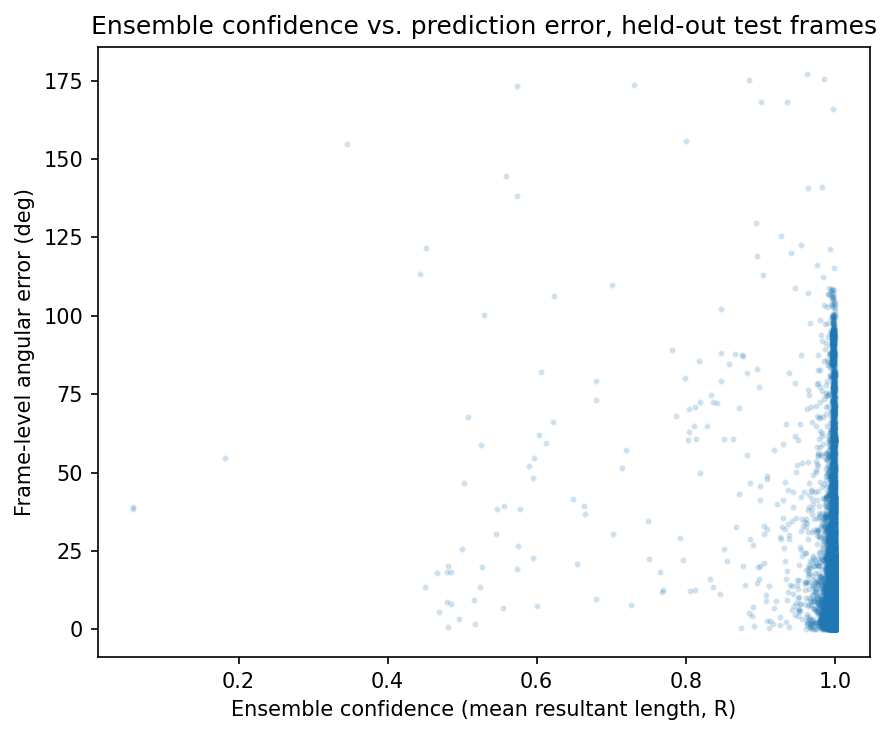

In [17]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
ax.scatter(calib_df['confidence_R'], calib_df['abs_angular_error_deg'], s=4, alpha=0.15)
ax.set_xlabel('Ensemble confidence (mean resultant length, R)')
ax.set_ylabel('Frame-level angular error (deg)')
ax.set_title('Ensemble confidence vs. prediction error, held-out test frames')
fig.tight_layout()
fig.savefig('../figures/reviewer_response_ensemble_confidence_calibration.svg', format='svg')
plt.show()

**Significance:** This answers Reviewer #1 (major comments 12-13). The ensemble-agreement confidence measure is genuinely informative, not just a plausible-sounding suggestion: median error roughly doubles from the highest-agreement quartile (3.93 deg) to the lowest (7.72 deg) — a real, checkable safety mechanism the manuscript could adopt for flagging unreliable predictions. The out-of-distribution range check is more of a null finding worth reporting honestly rather than omitting: the external David dataset is *not* flagged more often than the model's own held-out test set on these 6 kinematic variables (4.8% vs. 21.4%) — this specific check cannot defend the Introduction's "arbitrary free-flight trajectories" claim, so that language needs to be narrowed in the manuscript text regardless of what this diagnostic shows (item 14 in the plan).

## 7. Summary

This notebook, together with `model_training_based_on_reviewer_feedback.ipynb`, now
covers all eleven "Essential" and "Strongly recommended" items in
`plan_for_addressing_some_concerns.txt`. New artifacts written by this notebook:

- `pipelinedata/reviewer_response/dataset_flow_table.csv`
- `pipelinedata/reviewer_response/input_valid_ranges.csv`
- `models/model_reviewer_response_full_seed{7,13,99}.keras`
- `figures/reviewer_response_ensemble_confidence_calibration.svg`

Remaining open items are exactly the "Manuscript/administrative" section of the plan:
reconciling the manuscript's numeric claims and paper-version mismatch, the data/code/
funding availability statements, and narrowing broad applicability language — none of
which are code changes, and are best handled directly in the manuscript text.

One procedural item from "Strongly recommended" #8 could not be answered from the
repository alone and needs a direct answer from whoever ran the original preprocessing:
**whether the correction-procedure's parameters (alpha2/alpha1, the pi/2 filtering
threshold, the Savitzky-Golay settings) were chosen before or after looking at what
would later become the test trajectories.** This notebook confirms what the parameters'
values are and how sensitive results are to them, but not the order in which they were
selected relative to train/test partitioning in the original (pre-this-response) work.